In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from moabb.paradigms import P300,LeftRightImagery, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = LeftRightImagery(resample=250)
dataset = BNCI2014004()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[3],
     return_epochs=True
)
session = meta['session'][1]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


Sampling frequency of the instance is already 250.0, returning unmodified.
Not setting metadata
120 matching events found
No baseline correction applied
Sampling frequency of the instance is already 250.0, returning unmodified.
Not setting metadata
120 matching events found
No baseline correction applied
Sampling frequency of the instance is already 250.0, returning unmodified.
Not setting metadata
160 matching events found
No baseline correction applied
Sampling frequency of the instance is already 250.0, returning unmodified.
Not setting metadata
160 matching events found
No baseline correction applied
Sampling frequency of the instance is already 250.0, returning unmodified.
Not setting metadata
160 matching events found
No baseline correction applied
Not setting metadata
720 matching events found
No baseline correction applied


In [3]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.tensorize import stf_tensor
from mne.decoding import Scaler

X = epochs.get_data()
X = Scaler(scalings='mean', with_mean=True).fit_transform(X)
X = stf_tensor(X, sfreq=epochs.info['sfreq'], zscore=True)
X = tl.tensor(X)
y = labels
X.shape

/tmp/ipykernel_866/705532774.py:7: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(120, 3, 16, 72)

In [4]:
import numpy as np
np.any(X==0)

array(False)

In [5]:
%env PYTHONWARNINGS=ignore::FutureWarning

env: PYTHONWARNINGS=ignore::FutureWarning


In [6]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFwe
from hoda.classification import SelectF

clf = make_pipeline(
    SelectF(alpha=.05),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

bttda = GreedyBTTDA(
    max_blocks=4,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='oas',
        toeplitz=None,#(1,),
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
    ),
    verbose=True,
    extra_train_info=True,
    n_jobs=1,
    cv= StratifiedKFold(random_state=42,shuffle=True),
    truncate=True,
    clf=clf,
)
bttda.fit(X,y, test=True)

Model selection block 1/4...

Trying rank (1, 1, 1)	score: 0.4126
Trying rank (2, 2, 2)	score: 0.5494
Trying rank (3, 4, 4)	score: 0.5120
Trying rank (3, 8, 8)	score: 0.3971
Trying rank (3, 16, 16)	score: 0.4806

Selected rank (2, 2, 2) with score 0.5494
New ranks: [(2, 2, 2)]


Model selection block 2/4...

Trying rank (1, 1, 1)	score: 0.5569
Trying rank (2, 2, 2)	score: 0.5362
Trying rank (3, 4, 4)	score: 0.5104
Trying rank (3, 8, 8)	score: 0.5363
Trying rank (3, 16, 16)	score: 0.4910

Selected rank (1, 1, 1) with score 0.5569
New ranks: [(2, 2, 2), (1, 1, 1)]


Model selection block 3/4...

Trying rank (1, 1, 1)	score: 0.5493
Trying rank (2, 2, 2)	score: 0.5472
Trying rank (3, 4, 4)	score: 0.5439
Trying rank (3, 8, 8)	score: 0.5536
Trying rank (3, 16, 16)	score: 0.5184

Selected rank (3, 8, 8) with score 0.5536
New ranks: [(2, 2, 2), (1, 1, 1), (3, 8, 8)]


Model selection block 4/4...

Trying rank (1, 1, 1)	score: 0.5289
Trying rank (2, 2, 2)	score: 0.5436
Trying rank (3, 4, 4)	sco

GreedyBTTDA(clf=Pipeline(steps=[('selectf', SelectF(alpha=0.05)),
                                ('functiontransformer',
                                 FunctionTransformer(func=<function CupyBackend.to_numpy at 0x7faeb4370b80>)),
                                ('standardscaler', StandardScaler()),
                                ('lineardiscriminantanalysis',
                                 LinearDiscriminantAnalysis(shrinkage='auto',
                                                            solver='lsqr'))]),
            cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
            extra_train_info=True,
            hoda_params={'delta': None, 'extra_train_info': False,
                         'init': 'random', 'max_iter': 128, 'obj': 'tr',
                         'random_state': 42, 'rank': (3, 8, 8),
                         'shrinkage': 'oas', 'solver': 'lanczos',
                         'taper': False, 'toeplitz': None, 'tol': 1e-08,
                         'verbose': False},
            max_blocks=4, n_jobs=1, verbose=True)

In [7]:
bttda.model_select_info_.groupby(['block', 'rank']).val_score.aggregate('mean')

block  rank       
0      (1, 1, 1)      0.412626
       (2, 2, 2)      0.549444
       (3, 4, 4)      0.511970
       (3, 8, 8)      0.397071
       (3, 16, 16)    0.480606
1      (1, 1, 1)      0.556869
       (2, 2, 2)      0.536212
       (3, 4, 4)      0.510354
       (3, 8, 8)      0.536263
       (3, 16, 16)    0.491010
2      (1, 1, 1)      0.549293
       (2, 2, 2)      0.547172
       (3, 4, 4)      0.543939
       (3, 8, 8)      0.553636
       (3, 16, 16)    0.518384
3      (1, 1, 1)      0.528939
       (2, 2, 2)      0.543586
       (3, 4, 4)      0.532323
       (3, 8, 8)      0.575202
       (3, 16, 16)    0.545758
Name: val_score, dtype: float64

In [8]:
Xt = bttda.transform(X)

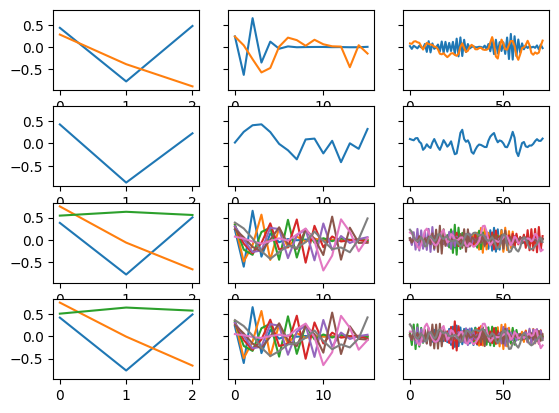

In [9]:
fig, axs = plt.subplots(bttda.n_blocks_,3, sharey=True)
for b,block in enumerate(bttda.blocks_):
    for k in range(3):
        axs[b,k].plot(tl.to_numpy(block.weights_[k]))



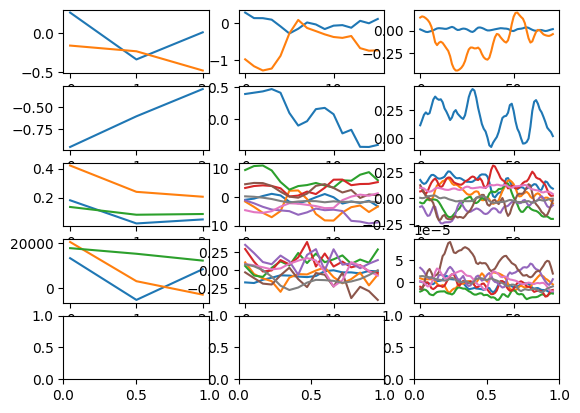

In [10]:
fig, axs = plt.subplots(5,3, sharey=False)
for b,block in enumerate(bttda.blocks_[:5]):
    for k in range(3):
        axs[b,k].plot(tl.to_numpy(block.aps_[k]))

block  rank  n_features
0      2     1             0.956944
1      2     1             0.956944
2      2     1             0.956944
3      3     1             0.956944
Name: val_score, dtype: float64

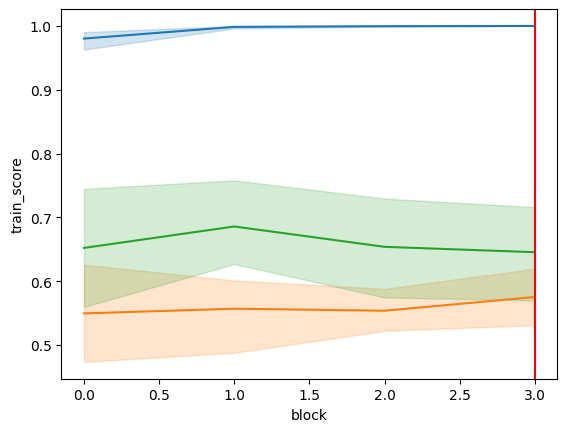

In [11]:
import seaborn as sns 
import matplotlib.pyplot as plt
df_select = bttda.model_select_info_best_
plt.style.use('default')
sns.lineplot(data=df_select, x='block',y='train_score')
sns.lineplot(data=df_select, x='block',y='val_score')
sns.lineplot(data=df_select, x='block',y='test_score')

plt.axvline(bttda.n_blocks_-1, color='red')

<Axes: xlabel='block', ylabel='nmse'>

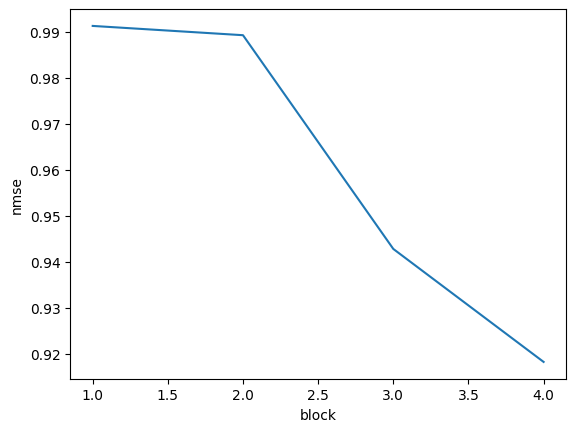

In [12]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.lineplot(data=bttda.train_info_, x='block',y='nmse')